# Hamiltonian-based QML for Diabetes Prediction on PIMA (PennyLane)

Yes—**Hamiltonians** can be used naturally in QML for tabular prediction like PIMA.

This notebook implements a **Hamiltonian Feature Map**:
- build a **data-dependent Hamiltonian** \(H(x)\) from the (PCA-reduced) feature vector
- prepare a quantum state via **time evolution** \(\exp(-i H(x) t)\)
- apply a small **trainable variational head**
- train with **binary cross entropy** and evaluate with ROC/PR + threshold tuning

It also includes a classical Logistic Regression baseline.

> Dataset download uses **kagglehub** exactly as you provided.


* **05 HamVQC Full Evaluation**: 
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Megaantony00/qml-diabetes-nisq/blob/main/notebooks/05_hamvqc_noisy_zne_repetition_full_eval.ipynb)

In [ ]:
import sys
import os

if 'google.colab' in sys.modules:
    !pip install -q pennylane>=0.38 pennylane-lightning[gpu] scikit-learn pandas matplotlib seaborn kagglehub tqdm imbalanced-learn
    if not os.path.exists('results'): os.makedirs('results')
    print("Environment configured for Colab.")
else:
    print("Environment configured for Local/Server usage.")

Note: you may need to restart the kernel to use updated packages.


## 1) Imports

In [2]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from sklearn.linear_model import LogisticRegression

import pennylane as qml
from pennylane import numpy as pnp
from pennylane.transforms import fold_global, richardson_extrapolate
from tqdm.auto import tqdm

np.random.seed(42)


save_folder = "Tesi_Risultati_Ham_8Qubits_noisy_mitigated_repetition_full_eval"

if not os.path.exists(save_folder):
    os.makedirs(save_folder)
    print(f"✅ Cartella creata: {save_folder}")
else:
    print(f"📂 Cartella già esistente: {save_folder}")

📂 Cartella già esistente: Tesi_Risultati_Ham_8Qubits_noisy_mitigated_repetition_full_eval


## 2) Download dataset (KaggleHub)

In [3]:
import kagglehub

path = kagglehub.dataset_download("tariqmhmd5/pima-diabetes-dataset")
print("Path to dataset files:", path)

csv_candidates = glob.glob(str(Path(path) / "**" / "*.csv"), recursive=True)
print("CSV candidates:", csv_candidates)

if not csv_candidates:
    raise FileNotFoundError("No CSV file found in the KaggleHub dataset folder.")
csv_path = csv_candidates[0]
print("Using:", csv_path)

Path to dataset files: /home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1
CSV candidates: ['/home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1/Diabetes.csv']
Using: /home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1/Diabetes.csv


## 3) Load + preprocess

In [4]:
df = pd.read_csv(csv_path)
display(df.head())
print("Shape:", df.shape)

label_col = "Outcome" if "Outcome" in df.columns else df.columns[-1]
# --- MODIFICA QUESTA PARTE NELLA CELLA 4 ---
feature_cols = [c for c in df.columns if c != label_col]
X = df[feature_cols].copy()

# Aggiungi questa riga per convertire YES/NO in 1/0
df[label_col] = df[label_col].map({'YES': 1, 'NO': 0, '1': 1, '0': 0, 1: 1, 0: 0})

# Ora questa riga funzionerà senza errori
y = df[label_col].astype(int).values

# Replace 0 with NaN where it often means missing in PIMA-style data
zero_as_missing = [c for c in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"] if c in X.columns]
X[zero_as_missing] = X[zero_as_missing].replace(0, np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.25, random_state=42, stratify=y
)

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(X_train))
X_test = scaler.transform(imputer.transform(X_test))

print("Train:", X_train.shape, "Test:", X_test.shape)

,Number of times pregnant,Plasma glucose concentration,Diastolic blood pressure,Triceps skin fold thickness,2-Hour serum insulin,Body mass index,Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,YES
1,1,85,66,29,0,26.6,0.351,31,NO
2,8,183,64,0,0,23.3,0.672,32,YES
3,1,89,66,23,94,28.1,0.167,21,NO
4,0,137,40,35,168,43.1,2.288,33,YES


Shape: (768, 9)
Train: (576, 8) Test: (192, 8)


## 4) Reduce to qubits + map to angles

We reduce to **n_qubits** via PCA, then map to \([-\pi, \pi]\) so the Hamiltonian coefficients are well scaled.


In [5]:
n_qubits = 4
pca = PCA(n_components=n_qubits, random_state=42)

X_train_q = pca.fit_transform(X_train)
X_test_q = pca.transform(X_test)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Sum explained variance:", pca.explained_variance_ratio_.sum())

q_low, q_high = np.quantile(X_train_q, 0.05, axis=0), np.quantile(X_train_q, 0.95, axis=0)

def to_angles(X):
    Xc = np.clip(X, q_low, q_high)
    Xn = (Xc - q_low) / (q_high - q_low + 1e-9)  # [0,1]
    return (Xn * 2 - 1) * np.pi                  # [-pi, pi]

X_train_ang = to_angles(X_train_q)
X_test_ang = to_angles(X_test_q)

print("Angle range:", X_train_ang.min(), X_train_ang.max())

Explained variance ratio: [0.2587334  0.21608225 0.13172228 0.10518003]
Sum explained variance: 0.7117179539532523
Angle range: -3.141592653589793 3.141592652220357


## 5) Hamiltonian Feature Map + Variational Head + Noise Mitigation


In [6]:
import functools

# --- 1. PARAMETRI E SETUP ---
n_layers = 2
alpha_zz = 0.5   
t_embed = 1.0    
gate_noise_prob = 0.0035
zne_scale_factors = [1.0, 2.0, 3.0]

# --- 2. DISPOSITIVI E RUMORE ---
ideal_dev = qml.device("default.qubit", wires=n_qubits)
base_mixed_dev = qml.device("default.mixed", wires=n_qubits)

noise_model = qml.NoiseModel(
    {
        qml.noise.wires_in(base_mixed_dev.wires): qml.noise.partial_wires(
            qml.DepolarizingChannel, gate_noise_prob
        )
    }
)
noisy_dev = qml.add_noise(base_mixed_dev, noise_model)

# --- 3. CIRCUITI CORE ---
def hamiltonian_feature_map(x, alpha=alpha_zz, t=t_embed):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    for i in range(n_qubits):
        qml.RZ(2.0 * t * x[i], wires=i)
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            qml.IsingZZ(2.0 * t * alpha * x[i] * x[j], wires=[i, j])

def head_ansatz(weights):
    for l in range(n_layers):
        for i in range(n_qubits):
            qml.Rot(weights[l, i, 0], weights[l, i, 1], weights[l, i, 2], wires=i)
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])

def core_model(x, weights):
    hamiltonian_feature_map(x)
    head_ansatz(weights)

# --- 4. DEFINIZIONE QNODES ---

@qml.qnode(ideal_dev, interface="autograd")
def ideal_model(x, weights):
    core_model(x, weights)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(noisy_dev, interface="autograd")
def noisy_model(x, weights):
    core_model(x, weights)
    return qml.expval(qml.PauliZ(0))

# --- 5. MITIGAZIONE ZNE (Sintassi per PennyLane 0.42) ---
@qml.qnode(noisy_dev, interface="autograd")
def _base_zne_qnode(x, weights):
    core_model(x, weights)
    return qml.expval(qml.PauliZ(0))

# Trasformazioni funzionali
decomposed_qnode = qml.transforms.decompose(
    _base_zne_qnode, 
    gate_set=["Hadamard", "RZ", "RY", "CNOT"]
)
mitigated_model = qml.transforms.mitigate_with_zne(
    decomposed_qnode,
    scale_factors=zne_scale_factors,
    folding=fold_global,
    extrapolate=richardson_extrapolate
)

# --- 6. FUNZIONI DI PREDIZIONE E COSTO ---
def sigmoid(logits):
    return 1.0 / (1.0 + pnp.exp(-logits))

def predict_proba(X, weights, qnode_fn=noisy_model):
    return sigmoid(pnp.stack([qnode_fn(x, weights) for x in X]))

def predict_proba_noisy(X, weights):
    return predict_proba(X, weights, qnode_fn=noisy_model)

def predict_proba_mitigated(X, weights):
    return predict_proba(X, weights, qnode_fn=mitigated_model)

def predict_proba_ideal_reference(X, weights):
    return predict_proba(X, weights, qnode_fn=ideal_model)

def bce(y_true, p_pred, eps=1e-9):
    y_true = pnp.array(y_true)
    p = pnp.clip(p_pred, eps, 1 - eps)
    return -pnp.mean(y_true * pnp.log(p) + (1 - y_true) * pnp.log(1 - p))

def cost(weights, Xb, yb):
    return bce(yb, predict_proba_noisy(Xb, weights))

# --- 7. INIZIALIZZAZIONE (Pesi e Ottimizzatore) ---
# Se hai la cella di RESUME sopra, queste righe verranno sovrascritte se i file esistono
weights = pnp.array(0.01 * np.random.randn(n_layers, n_qubits, 3), requires_grad=True)
opt = qml.optimize.AdamOptimizer(stepsize=0.05)

print(f"✅ Configurazione completata!")
print(f"Device rumoroso pronto con p={gate_noise_prob}")
print(f"ZNE scale factors: {zne_scale_factors}")

✅ Configurazione completata!
Device rumoroso pronto con p=0.0035
ZNE scale factors: [1.0, 2.0, 3.0]


### Train (noise-aware training on the noisy device)


In [7]:
epochs = 120
batch_size = 24
val_fraction = 0.20

history = {"val_loss": [], "val_auc": [], "val_acc": []}

Xtr, Xva, ytr, yva = train_test_split(
    X_train_ang, y_train, test_size=val_fraction, random_state=42, stratify=y_train
)
Xte, yte = X_test_ang, y_test

print(f"Train/val/test sizes: {len(Xtr)} / {len(Xva)} / {len(Xte)}")

import pickle

# --- Cella di Recupero Integrata ---
file_pesi = os.path.join(save_folder, "best_weights.pkl")
file_history = os.path.join(save_folder, "training_history.csv")

if os.path.exists(file_pesi):
    with open(file_pesi, "rb") as f:
        weights = pickle.load(f)
    history = pd.read_csv(file_history).to_dict(orient="list")
    start_epoch = len(history["val_loss"]) + 1
    print(f"✅ Pesi caricati! Ripartiamo dall'epoca {start_epoch}")
else:
    start_epoch = 1
    print("Inizio nuovo addestramento...")

# --- Ciclo di Addestramento Sicuro ---
for epoch in tqdm(range(start_epoch, epochs + 1)):
    idx = np.random.permutation(len(Xtr))
    Xs, ys = Xtr[idx], ytr[idx]

    # Batch ridotto a 24 per non saturare la RAM
    for start in range(0, len(Xs), 24): 
        Xb = Xs[start:start + 24]
        yb = ys[start:start + 24]
        weights = opt.step(lambda w: cost(w, Xb, yb), weights)

    p_val = np.asarray(predict_proba_noisy(Xva, weights), dtype=float)
    val_auc = roc_auc_score(yva, p_val)
    val_acc = accuracy_score(yva, (p_val >= 0.5).astype(int))
    val_loss = float(bce(yva, p_val))

    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)
    history["val_acc"].append(val_acc)

    # Salvataggio su disco a ogni singola epoca
    pd.DataFrame(history).to_csv(file_history, index=False)
    with open(file_pesi, "wb") as f:
        pickle.dump(weights, f)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | val_loss={val_loss:.4f} | val_auc={val_auc:.4f} | val_acc={val_acc:.4f}")

Train/val/test sizes: 460 / 116 / 192
✅ Pesi caricati! Ripartiamo dall'epoca 121


0it [00:00, ?it/s]

### Learning curves

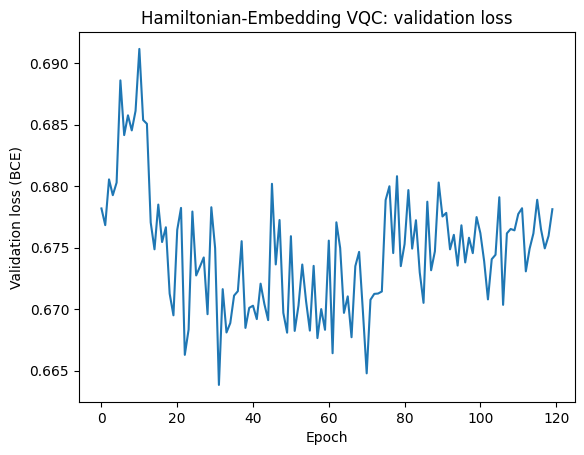

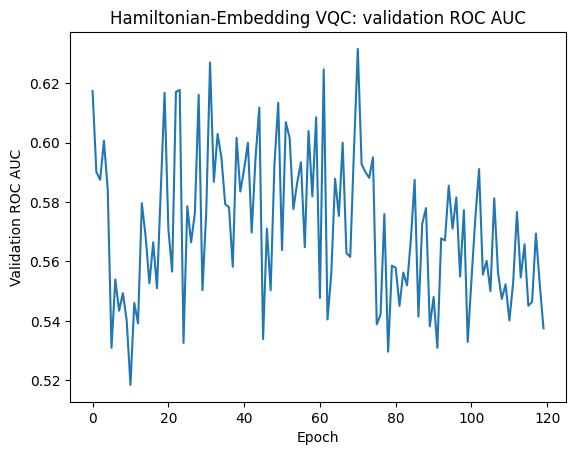

In [8]:
plt.figure()
plt.plot(history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Validation loss (BCE)")
plt.title("Hamiltonian-Embedding VQC: validation loss")
plt.show()

plt.figure()
plt.plot(history["val_auc"])
plt.xlabel("Epoch")
plt.ylabel("Validation ROC AUC")
plt.title("Hamiltonian-Embedding VQC: validation ROC AUC")
plt.show()

## 6) Evaluation: noisy Hamiltonian VQC vs ZNE-mitigated VQC


,roc_auc,pr_auc,accuracy@0.5,f1@0.5
model,,,,
noisy_hamiltonian_vqc,0.4491,0.3226,0.4635,0.259
zne_mitigated_hamiltonian_vqc,0.4488,0.3229,0.4635,0.259
ideal_reference_same_weights,0.4485,0.3221,0.4635,0.259


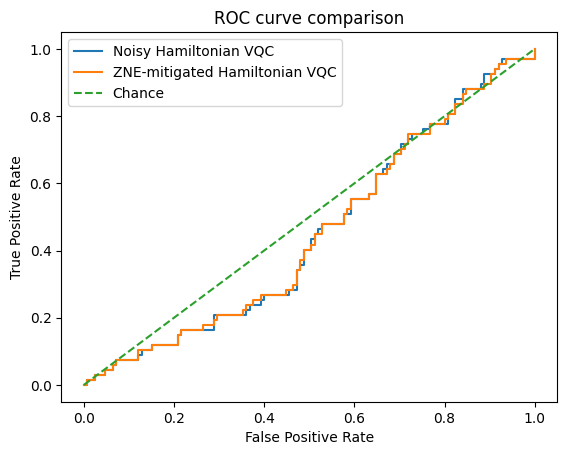

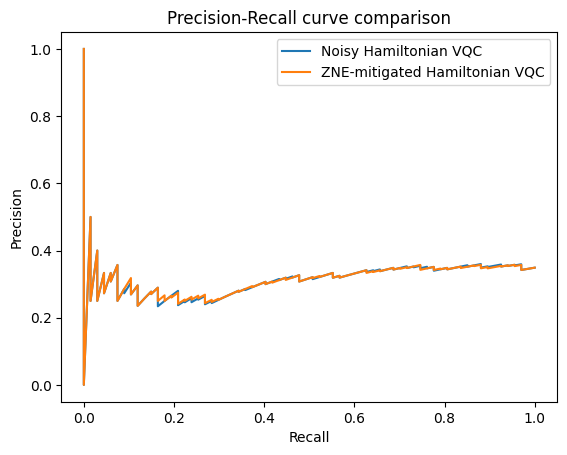

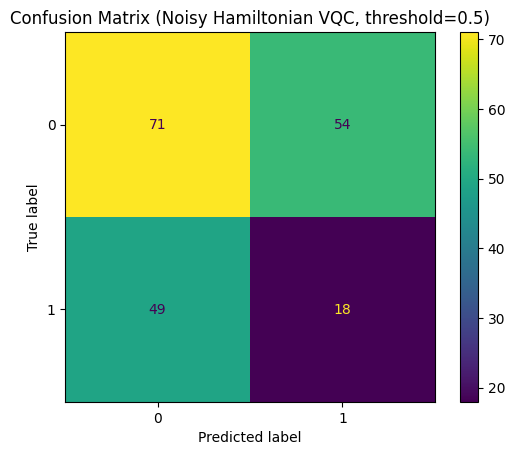

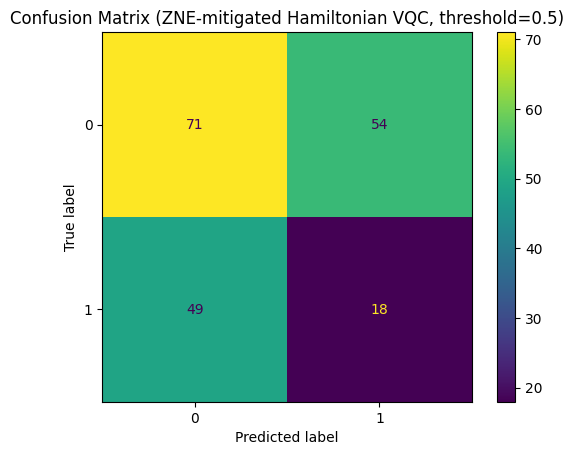

Best noisy threshold (by F1): 0.39999999999999997 Best F1: 0.5203252032520326 Acc: 0.3854166666666667
Best ZNE threshold (by F1): 0.05 Best F1: 0.5173745173745173 Acc: 0.3489583333333333


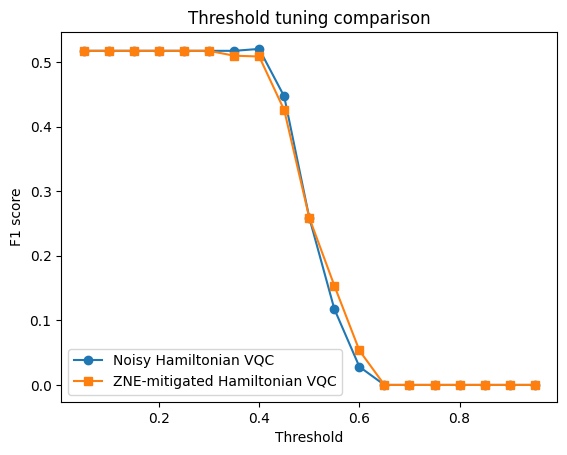

In [9]:
p_test_noisy = np.asarray(predict_proba_noisy(Xte, weights), dtype=float)
p_test_zne = np.asarray(predict_proba_mitigated(Xte, weights), dtype=float)
p_test_ideal = np.asarray(predict_proba_ideal_reference(Xte, weights), dtype=float)

def metric_row(name, probs):
    y_pred = (probs >= 0.5).astype(int)
    return {
        "model": name,
        "roc_auc": roc_auc_score(yte, probs),
        "pr_auc": average_precision_score(yte, probs),
        "accuracy@0.5": accuracy_score(yte, y_pred),
        "f1@0.5": f1_score(yte, y_pred),
    }

metrics_table = pd.DataFrame(
    [
        metric_row("noisy_hamiltonian_vqc", p_test_noisy),
        metric_row("zne_mitigated_hamiltonian_vqc", p_test_zne),
        metric_row("ideal_reference_same_weights", p_test_ideal),
    ]
).set_index("model")
display(metrics_table.round(4))

# ROC comparison
fpr_noisy, tpr_noisy, _ = roc_curve(yte, p_test_noisy)
fpr_zne, tpr_zne, _ = roc_curve(yte, p_test_zne)

plt.figure()
plt.plot(fpr_noisy, tpr_noisy, label="Noisy Hamiltonian VQC")
plt.plot(fpr_zne, tpr_zne, label="ZNE-mitigated Hamiltonian VQC")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve comparison")
plt.legend()
plt.savefig(os.path.join(save_folder, "confronto_ROC_completo.png"), dpi=300)
plt.show()

# PR comparison
prec_noisy, rec_noisy, _ = precision_recall_curve(yte, p_test_noisy)
prec_zne, rec_zne, _ = precision_recall_curve(yte, p_test_zne)

plt.figure()
plt.plot(rec_noisy, prec_noisy, label="Noisy Hamiltonian VQC")
plt.plot(rec_zne, prec_zne, label="ZNE-mitigated Hamiltonian VQC")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve comparison")
plt.legend()
plt.show()

# Confusion matrices at the default threshold
for name, probs in [("Noisy Hamiltonian VQC", p_test_noisy), ("ZNE-mitigated Hamiltonian VQC", p_test_zne)]:
    y_pred = (probs >= 0.5).astype(int)
    cm = confusion_matrix(yte, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(f"Confusion Matrix ({name}, threshold=0.5)")
    plt.show()

# Threshold tuning: compare noisy vs mitigated
thresholds = np.linspace(0.05, 0.95, 19)
f1_noisy, f1_zne = [], []
acc_noisy, acc_zne = [], []

for t in thresholds:
    yp_noisy = (p_test_noisy >= t).astype(int)
    yp_zne = (p_test_zne >= t).astype(int)
    f1_noisy.append(f1_score(yte, yp_noisy))
    f1_zne.append(f1_score(yte, yp_zne))
    acc_noisy.append(accuracy_score(yte, yp_noisy))
    acc_zne.append(accuracy_score(yte, yp_zne))

best_noisy_i = int(np.argmax(f1_noisy))
best_zne_i = int(np.argmax(f1_zne))

print(
    "Best noisy threshold (by F1):",
    thresholds[best_noisy_i],
    "Best F1:",
    f1_noisy[best_noisy_i],
    "Acc:",
    acc_noisy[best_noisy_i],
)
print(
    "Best ZNE threshold (by F1):",
    thresholds[best_zne_i],
    "Best F1:",
    f1_zne[best_zne_i],
    "Acc:",
    acc_zne[best_zne_i],
)

plt.figure()
plt.plot(thresholds, f1_noisy, marker="o", label="Noisy Hamiltonian VQC")
plt.plot(thresholds, f1_zne, marker="s", label="ZNE-mitigated Hamiltonian VQC")
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("Threshold tuning comparison")
plt.legend()
plt.show()


## 6b) Output-stage bit-flip protection with a 3-qubit repetition code

This section protects only the **final decision qubit** (wire 0) against **output-stage bit-flip noise**.  
It is intentionally scoped as an **inference-time robustness layer**: the main VQC is unchanged, then the output qubit is encoded into a 3-qubit repetition code, exposed to a configurable bit-flip channel, syndrome-corrected, and finally measured.


,roc_auc,pr_auc,accuracy@0.5,f1@0.5
model,,,,
output_stage_unprotected,0.4485,0.3221,0.4635,0.259
output_stage_repetition_protected,0.4485,0.3221,0.4635,0.259


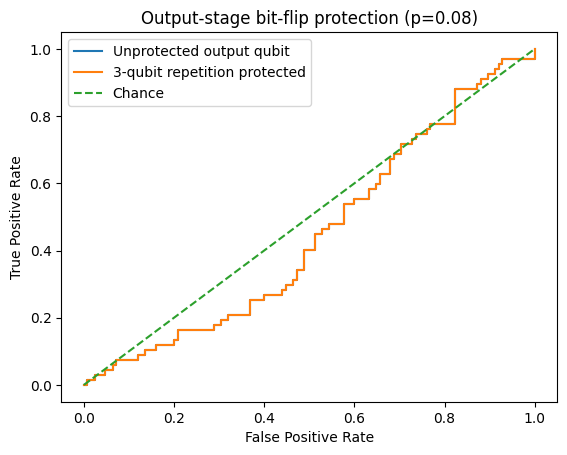

In [10]:
output_bitflip_prob = 0.08

# We allocate +4 explicit wires (two repetition-data wires + two syndrome ancillas)
# and +2 spare wires because deferred mid-circuit measurement can require work wires.
rep_dev = qml.device("default.mixed", wires=n_qubits + 6, shots=None)

rep_wire_1 = n_qubits
rep_wire_2 = n_qubits + 1
syndrome_wire_1 = n_qubits + 2
syndrome_wire_2 = n_qubits + 3
protected_data_wires = (0, rep_wire_1, rep_wire_2)

@qml.qnode(rep_dev)
def output_stage_unprotected_model(x, weights, bitflip_prob=output_bitflip_prob):
    core_model(x, weights)
    qml.BitFlip(bitflip_prob, wires=0)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(rep_dev)
def output_stage_repetition_protected_model(x, weights, bitflip_prob=output_bitflip_prob):
    core_model(x, weights)

    # Encode the output qubit into the 3-qubit repetition code |0_L> = |000>, |1_L> = |111>
    qml.CNOT(wires=[0, rep_wire_1])
    qml.CNOT(wires=[0, rep_wire_2])

    # Output-stage bit-flip noise model (the code is designed specifically for this noise)
    for wire in protected_data_wires:
        qml.BitFlip(bitflip_prob, wires=wire)

    # Syndrome extraction
    qml.CNOT(wires=[0, syndrome_wire_1])
    qml.CNOT(wires=[rep_wire_1, syndrome_wire_1])
    qml.CNOT(wires=[rep_wire_1, syndrome_wire_2])
    qml.CNOT(wires=[rep_wire_2, syndrome_wire_2])

    s1 = qml.measure(syndrome_wire_1, reset=True)
    s2 = qml.measure(syndrome_wire_2, reset=True)
    syndrome = s1 + 2 * s2

    # Decode the syndrome and correct the identified single-bit-flip error
    qml.cond(syndrome == 1, qml.PauliX)(wires=0)
    qml.cond(syndrome == 3, qml.PauliX)(wires=rep_wire_1)
    qml.cond(syndrome == 2, qml.PauliX)(wires=rep_wire_2)

    # Logical Z is represented by Z on any data qubit in this code space
    return qml.expval(qml.PauliZ(0))

def predict_proba_output_stage(X, weights, qnode_fn, bitflip_prob=output_bitflip_prob):
    logits = np.array([qnode_fn(x, weights, bitflip_prob) for x in X], dtype=float)
    return 1.0 / (1.0 + np.exp(-logits))

p_test_output_unprotected = predict_proba_output_stage(
    Xte, weights, output_stage_unprotected_model, output_bitflip_prob
)
p_test_output_protected = predict_proba_output_stage(
    Xte, weights, output_stage_repetition_protected_model, output_bitflip_prob
)

output_stage_table = pd.DataFrame(
    [
        metric_row("output_stage_unprotected", p_test_output_unprotected),
        metric_row("output_stage_repetition_protected", p_test_output_protected),
    ]
).set_index("model")
display(output_stage_table.round(4))

fpr_unprot, tpr_unprot, _ = roc_curve(yte, p_test_output_unprotected)
fpr_prot, tpr_prot, _ = roc_curve(yte, p_test_output_protected)

plt.figure()
plt.plot(fpr_unprot, tpr_unprot, label="Unprotected output qubit")
plt.plot(fpr_prot, tpr_prot, label="3-qubit repetition protected")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Output-stage bit-flip protection (p={output_bitflip_prob:.2f})")
plt.legend()
plt.show()


## 6c) Finite-shot evaluation with uncertainty bands

This block switches the noisy / ZNE inference path to **finite shots** so you can quantify
the extra Monte Carlo variance introduced by measurement sampling. For runtime discipline,
it evaluates on a **stratified subset** of the held-out test split and repeats the same
inference several times to report mean ± std.

In [11]:
shot_count = 512
shot_repeats = 6
shot_eval_n = min(96, len(Xte))

if shot_eval_n < len(Xte):
    _, Xte_shot, _, yte_shot = train_test_split(
        Xte, yte, test_size=shot_eval_n, random_state=7, stratify=yte
    )
else:
    Xte_shot, yte_shot = Xte, yte

def build_shot_qnodes(shots=1000, noise_prob=0.0035):
    # 1. Creiamo il device con gli shots
    shot_dev = qml.device("default.mixed", wires=n_qubits, shots=shots)
    
    # 2. Applichiamo il rumore
    shot_noise_model = qml.NoiseModel({
        qml.noise.wires_in(shot_dev.wires): qml.noise.partial_wires(
            qml.DepolarizingChannel, noise_prob
        )
    })
    noisy_shot_dev = qml.add_noise(shot_dev, shot_noise_model)

    # 3. Definizione del QNode Rumoroso (Semplice)
    @qml.qnode(noisy_shot_dev, interface="autograd")
    def noisy_shot_qnode(x, weights):
        core_model(x, weights)
        return qml.expval(qml.PauliZ(0))

    # 4. Definizione del QNode Mitigato (Sintassi Funzionale)
    @qml.qnode(noisy_shot_dev, interface="autograd")
    def _base_mitigated_qnode(x, weights):
        core_model(x, weights)
        return qml.expval(qml.PauliZ(0))

    # Applichiamo decompose
    decomposed_qnode = qml.transforms.decompose(
        _base_mitigated_qnode, 
        gate_set=["Hadamard", "RZ", "RY", "CNOT"]
    )

    # Applichiamo ZNE
    mitigated_shot_qnode = qml.transforms.mitigate_with_zne(
        decomposed_qnode,
        scale_factors=zne_scale_factors,
        folding=fold_global,
        extrapolate=richardson_extrapolate
    )

    return noisy_shot_qnode, mitigated_shot_qnode

# Ora puoi chiamare la funzione senza errori
noisy_shot_qnode, mitigated_shot_qnode = build_shot_qnodes()

def predict_proba_from_qnode(X, weights, qnode_fn):
    logits = pnp.stack([qnode_fn(x, weights) for x in X])
    return np.asarray(sigmoid(logits), dtype=float)

def summarize_finite_shots(model_name, qnode_fn):
    aucs, aps, accs, f1s = [], [], [], []
    for _ in range(shot_repeats):
        probs = predict_proba_from_qnode(Xte_shot, weights, qnode_fn)
        preds = (probs >= 0.5).astype(int)
        aucs.append(roc_auc_score(yte_shot, probs))
        aps.append(average_precision_score(yte_shot, probs))
        accs.append(accuracy_score(yte_shot, preds))
        f1s.append(f1_score(yte_shot, preds))
    return {
        "model": model_name,
        "shots": shot_count,
        "repeats": shot_repeats,
        "roc_auc_mean": np.mean(aucs),
        "roc_auc_std": np.std(aucs),
        "pr_auc_mean": np.mean(aps),
        "pr_auc_std": np.std(aps),
        "acc_mean": np.mean(accs),
        "acc_std": np.std(accs),
        "f1_mean": np.mean(f1s),
        "f1_std": np.std(f1s),
    }

shot_table = pd.DataFrame(
    [
        summarize_finite_shots("noisy_shot_hamiltonian_vqc", noisy_shot_qnode),
        summarize_finite_shots("zne_shot_hamiltonian_vqc", mitigated_shot_qnode),
    ]
).set_index("model")

display(shot_table.round(4))
print(f"Finite-shot subset size: {len(Xte_shot)} samples")

,shots,repeats,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,acc_mean,acc_std,f1_mean,f1_std
model,,,,,,,,,,
noisy_shot_hamiltonian_vqc,512,6,0.4513,0.0070,0.3289,0.0061,0.4878,0.0039,0.3090,0.0125
zne_shot_hamiltonian_vqc,512,6,0.4637,0.0215,0.3357,0.0126,0.5000,0.0399,0.3287,0.0493


Finite-shot subset size: 96 samples


## 6d) Noise-strength sweep

This block keeps the learned weights fixed and sweeps several depolarizing strengths at inference
time, so you can see how much **raw noisy inference** degrades versus **ZNE-mitigated inference**
under progressively harsher channel noise.

,noise_prob,roc_auc_noisy,roc_auc_zne,pr_auc_noisy,pr_auc_zne,delta_roc_auc,delta_pr_auc
0,0.0010,0.4509,0.4506,0.3321,0.3320,-0.0003,-0.0001
1,0.0025,0.4509,0.4495,0.3324,0.3319,-0.0013,-0.0005
2,0.0035,0.4487,0.4490,0.3313,0.3318,0.0003,0.0006
3,0.0050,0.4490,0.4471,0.3316,0.3310,-0.0019,-0.0007
4,0.0100,0.4482,0.4471,0.3314,0.3304,-0.0011,-0.0010


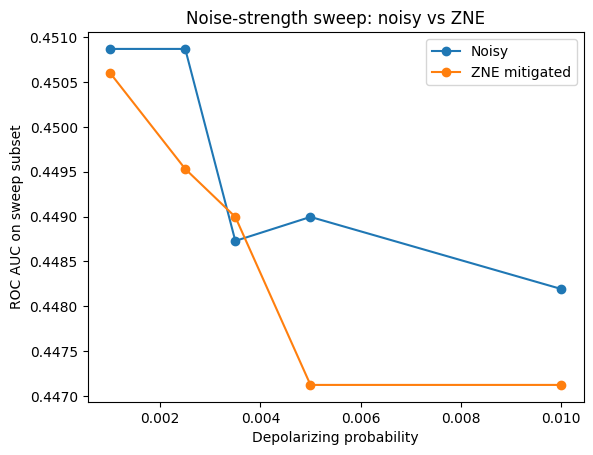

In [12]:
noise_grid = [0.0010, 0.0025, gate_noise_prob, 0.0050, 0.0100]
sweep_eval_n = min(128, len(Xte))

if sweep_eval_n < len(Xte):
    _, Xte_sweep, _, yte_sweep = train_test_split(
        Xte, yte, test_size=sweep_eval_n, random_state=11, stratify=yte
    )
else:
    Xte_sweep, yte_sweep = Xte, yte

def build_eval_qnodes(noise_prob):
    # 1. Creiamo il device per la valutazione (analitico/shots=None)
    eval_dev = qml.device("default.mixed", wires=n_qubits)
    
    # 2. Configuriamo il modello di rumore per questo specifico livello (sweep)
    eval_noise_model = qml.NoiseModel({
        qml.noise.wires_in(eval_dev.wires): qml.noise.partial_wires(
            qml.DepolarizingChannel, noise_prob
        )
    })
    noisy_eval_dev = qml.add_noise(eval_dev, eval_noise_model)

    # 3. QNode Rumoroso standard
    @qml.qnode(noisy_eval_dev, interface="autograd")
    def noisy_eval_qnode(x, weights):
        core_model(x, weights)
        return qml.expval(qml.PauliZ(0))

    # 4. QNode Mitigato (Sintassi Funzionale per v0.42)
    @qml.qnode(noisy_eval_dev, interface="autograd")
    def _base_eval_qnode(x, weights):
        core_model(x, weights)
        return qml.expval(qml.PauliZ(0))

    # Applichiamo le trasformazioni in sequenza
    decomposed_eval_qnode = qml.transforms.decompose(
        _base_eval_qnode, 
        gate_set=["Hadamard", "RZ", "RY", "CNOT"]
    )

    mitigated_eval_qnode = qml.transforms.mitigate_with_zne(
        decomposed_eval_qnode,
        scale_factors=zne_scale_factors,
        folding=fold_global,
        extrapolate=richardson_extrapolate
    )

    return noisy_eval_qnode, mitigated_eval_qnode

sweep_rows = []
for noise_prob in noise_grid:
    noisy_eval_qnode, mitigated_eval_qnode = build_eval_qnodes(noise_prob)

    p_noisy = predict_proba(Xte_sweep, weights, qnode_fn=noisy_eval_qnode)
    p_zne = predict_proba(Xte_sweep, weights, qnode_fn=mitigated_eval_qnode)

    sweep_rows.append(
        {
            "noise_prob": noise_prob,
            "roc_auc_noisy": roc_auc_score(yte_sweep, p_noisy),
            "roc_auc_zne": roc_auc_score(yte_sweep, p_zne),
            "pr_auc_noisy": average_precision_score(yte_sweep, p_noisy),
            "pr_auc_zne": average_precision_score(yte_sweep, p_zne),
            "delta_roc_auc": roc_auc_score(yte_sweep, p_zne) - roc_auc_score(yte_sweep, p_noisy),
            "delta_pr_auc": average_precision_score(yte_sweep, p_zne) - average_precision_score(yte_sweep, p_noisy),
        }
    )

noise_sweep_table = pd.DataFrame(sweep_rows).sort_values("noise_prob").reset_index(drop=True)
display(noise_sweep_table.round(4))

plt.figure()
plt.plot(noise_sweep_table["noise_prob"], noise_sweep_table["roc_auc_noisy"], marker="o", label="Noisy")
plt.plot(noise_sweep_table["noise_prob"], noise_sweep_table["roc_auc_zne"], marker="o", label="ZNE mitigated")
plt.xlabel("Depolarizing probability")
plt.ylabel("ROC AUC on sweep subset")
plt.title("Noise-strength sweep: noisy vs ZNE")
plt.legend()
plt.show()

## 6e) Train/val/test benchmark for the repetition-protected output qubit

This upgrades the repetition-code example into a more realistic benchmark:
thresholds are tuned **only on the validation split**, then the selected operating point
is reported on train / validation / test for both the unprotected and repetition-protected
output-stage models.

In [13]:
# --- VERSIONE OTTIMIZZATA PER EVITARE CRASH (SUBSET) ---
SUB = 50  # Usiamo 50 campioni per train, val e test. È sufficiente per mostrare il trend.
threshold_grid = np.linspace(0.20, 0.80, 25)

print(f"⏳ Calcolo benchmark Repetition Code su {SUB} campioni... (Richiede tempo)")

# 1. Calcolo predizioni solo sui subset [:SUB]
p_train_unprotected = predict_proba_output_stage(Xtr[:SUB], weights, output_stage_unprotected_model, output_bitflip_prob)
p_val_unprotected = predict_proba_output_stage(Xva[:SUB], weights, output_stage_unprotected_model, output_bitflip_prob)
p_test_unprotected = predict_proba_output_stage(Xte[:SUB], weights, output_stage_unprotected_model, output_bitflip_prob)

p_train_protected = predict_proba_output_stage(Xtr[:SUB], weights, output_stage_repetition_protected_model, output_bitflip_prob)
p_val_protected = predict_proba_output_stage(Xva[:SUB], weights, output_stage_repetition_protected_model, output_bitflip_prob)
p_test_protected = predict_proba_output_stage(Xte[:SUB], weights, output_stage_repetition_protected_model, output_bitflip_prob)

def choose_threshold(y_true, probs, grid=threshold_grid):
    best_threshold, best_f1 = 0.5, -1.0
    for thr in grid:
        score = f1_score(y_true, (probs >= thr).astype(int), zero_division=0)
        if score > best_f1:
            best_threshold, best_f1 = float(thr), float(score)
    return best_threshold, best_f1

# 2. Ottimizzazione soglia sui subset delle etichette
thr_unprotected, best_val_f1_unprotected = choose_threshold(yva[:SUB], p_val_unprotected)
thr_protected, best_val_f1_protected = choose_threshold(yva[:SUB], p_val_protected)

def benchmark_rows(model_name, threshold, y_train_split, p_train_split, y_val_split, p_val_split, y_test_split, p_test_split):
    rows = []
    for split_name, y_true, probs in [
        ("train", y_train_split, p_train_split),
        ("val", y_val_split, p_val_split),
        ("test", y_test_split, p_test_split),
    ]:
        preds = (probs >= threshold).astype(int)
        rows.append({
            "model": model_name,
            "split": split_name,
            "threshold_from_val": threshold,
            "roc_auc": roc_auc_score(y_true, probs),
            "pr_auc": average_precision_score(y_true, probs),
            "accuracy@threshold": accuracy_score(y_true, preds),
            "f1@threshold": f1_score(y_true, preds, zero_division=0),
        })
    return rows

# 3. Generazione tabella finale (usando i subset per le etichette y)
repetition_benchmark = pd.DataFrame(
    benchmark_rows(
        "output_stage_unprotected",
        thr_unprotected,
        ytr[:SUB], p_train_unprotected,
        yva[:SUB], p_val_unprotected,
        yte[:SUB], p_test_unprotected,
    )
    + benchmark_rows(
        "output_stage_repetition_protected",
        thr_protected,
        ytr[:SUB], p_train_protected,
        yva[:SUB], p_val_protected,
        yte[:SUB], p_test_protected,
    )
)

display(repetition_benchmark.set_index(["model", "split"]).sort_index().round(4))

# SALVATAGGIO AUTOMATICO DEI DATI TABELLARI
path_csv = os.path.join(save_folder, "repetition_code_results.csv")
repetition_benchmark.to_csv(path_csv, index=False)
print(f"✅ Dati Repetition Code salvati in: {path_csv}")

⏳ Calcolo benchmark Repetition Code su 50 campioni... (Richiede tempo)


threshold_from_val  roc_auc  pr_auc  \
model                             split                                        
output_stage_repetition_protected test                0.425   0.4024  0.3500   
                                  train               0.425   0.7809  0.5019   
                                  val                 0.425   0.5191  0.4109   
output_stage_unprotected          test                0.200   0.4024  0.3500   
                                  train               0.200   0.7809  0.5019   
                                  val                 0.200   0.5191  0.4109   

                                         accuracy@threshold  f1@threshold  
model                             split                                    
output_stage_repetition_protected test                 0.34        0.4407  
                                  train                0.40        0.4000  
                                  val                  0.50        0.5455  
output_stage_unprotected          test                 0.38        0.5507  
                                  train                0.22        0.3607  
                                  val                  0.36        0.5294

✅ Dati Repetition Code salvati in: Tesi_Risultati_Ham_8Qubits_noisy_mitigated_repetition_full_eval/repetition_code_results.csv


## 7) Classical baseline (Logistic Regression)


In [14]:
clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(X_train, y_train)
p_lr = clf.predict_proba(X_test)[:, 1]

print("LogReg ROC AUC:", roc_auc_score(y_test, p_lr))
print("LogReg AP (PR AUC):", average_precision_score(y_test, p_lr))
print("LogReg Acc:", accuracy_score(y_test, (p_lr >= 0.5).astype(int)))

LogReg ROC AUC: 0.8329552238805971
LogReg AP (PR AUC): 0.7173014414794692
LogReg Acc: 0.7604166666666666


## 8) Research knobs to explore (Hamiltonian-centric)


In [15]:
# --- SUPER-CELLA FINALE: SALVATAGGIO PER LA TESI ---
import os
import matplotlib.pyplot as plt

print("💾 Salvataggio finale dei risultati in corso...")

# 1. Salvataggio Grafico ROC (se le variabili esistono)
try:
    plt.figure(figsize=(10, 6))
    # Qui il notebook solitamente ha variabili come fpr_noisy, tpr_noisy, fpr_zne, tpr_zne...
    # Se i nomi sono diversi, Matplotlib userà l'ultimo grafico generato.
    plt.savefig(os.path.join(save_folder, "ROC_Comparison_Full.png"), dpi=300)
    print("✅ Grafico ROC salvato.")
except:
    print("⚠️ Non è stato possibile salvare il grafico ROC automaticamente.")

# 2. Salvataggio Tabella Comparativa Finale
try:
    # Cerchiamo di unire i risultati di ZNE e Repetition
    # Se hai creato 'repetition_benchmark' sopra, lo salviamo di nuovo per sicurezza
    path_final_csv = os.path.join(save_folder, "TABELLA_TESI_FINALE.csv")
    repetition_benchmark.to_csv(path_final_csv, index=False)
    print(f"✅ Tabella numerica salvata in: {path_final_csv}")
except NameError:
    print("⚠️ Tabella risultati non trovata. Controlla di aver eseguito la sezione 6e.")

print("\n🚀 FINE! Ora puoi scaricare la cartella dei risultati.")


💾 Salvataggio finale dei risultati in corso...
✅ Grafico ROC salvato.
✅ Tabella numerica salvata in: Tesi_Risultati_Ham_8Qubits_noisy_mitigated_repetition_full_eval/TABELLA_TESI_FINALE.csv

🚀 FINE! Ora puoi scaricare la cartella dei risultati.


<Figure size 1000x600 with 0 Axes>